# 05 — Autoencoders

**Dataset:** `drive_day_2026`

**Question:** Does nonlinear reconstruction beat equal-dimension PCA?

## Method

Train compact autoencoder on training windows. Compare held-out error with PCA fit on same split.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "lap_estimation").exists():
    ROOT = ROOT.parent
if not (ROOT / "lap_estimation").exists():
    raise FileNotFoundError("Repository root not found")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lap_estimation.plotting_learned import render_autoencoder_diagnostics
from lap_estimation.artifacts import load_experiment_metrics
from lap_estimation.config import RANDOM_SEED
from lap_estimation.data import prepare_recording_manifest
from lap_estimation.datasets import resolve_dataset
from lap_estimation.runners import run_experiment

DATASET_KEY = "drive_day_2026"
dataset = resolve_dataset(DATASET_KEY, ROOT)
ARTIFACT_ROOT = dataset.artifact_root
np.random.seed(RANDOM_SEED)
sns.set_theme(style="ticks", palette="colorblind", context="notebook")
manifest = prepare_recording_manifest(dataset)
manifest[["recording_id", "duration_s", "motion_status", "control_candidate", "clock_provenance", "split"]]

,recording_id,duration_s,motion_status,control_candidate,clock_provenance,split
0,07173121b1534f1eadb8b127005d4eff70872388074c2b...,21.9,moving_candidate,False,recorded_time_column,train
1,1a8433bf1168531d6f7c2deb5c37b27de5ddf1d9f65316...,21.9,moving_candidate,False,recorded_time_column,train
2,1cca7c275163fc193899535ebb0c13f26676e8568d3c8a...,37.9,moving_candidate,False,recorded_time_column,train
3,200a690cbeb5a4d9f415d6a933e60aa13a0cf5ee5c03c7...,57.8,moving_candidate,False,recorded_time_column,train
4,25aa01e1dcbaea32c062e01b0f782c938c34163fc58af1...,73.7,moving_candidate,False,recorded_time_column,train
5,2f775054c4e7bb342cf49e0ee66406e82353c274c103fc...,25.9,moving_candidate,False,recorded_time_column,train
6,382db1f8ede73f956341d7b461790125339762ec9d7cc9...,57.8,stationary_candidate,True,recorded_time_column,train
7,4c8d0190b666e26315ce16c862ca2e968d576e14537487...,21.9,moving_candidate,False,recorded_time_column,train
8,554af5ad576c1c1d069356649e3bd1e2699a5801f6a0fa...,17.9,stationary_candidate,True,recorded_time_column,train
9,564a12f3d813c10242613a907d2b4981e7296739ba9a56...,57.8,stationary_candidate,True,recorded_time_column,train


In [2]:
EXPERIMENT_OPTIONS = {'epochs': 25}
EXPERIMENT_OPTIONS

{'epochs': 25}

,task,split,metric,value,sample_count,reference_source
0,window_reconstruction,train,autoencoder_mse,0.199380,333,none
1,window_reconstruction,validation,autoencoder_mse,0.131569,108,none
2,window_reconstruction,test,autoencoder_mse,0.191110,59,none
3,window_reconstruction,all,autoencoder_mse,0.183757,500,none
4,window_reconstruction,train,pca_mse,0.153631,333,none
5,window_reconstruction,validation,pca_mse,0.100073,108,none
6,window_reconstruction,test,pca_mse,0.148769,59,none
7,window_reconstruction,all,pca_mse,0.141489,500,none


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
recording_id,500,21,667a6e15a4394db30d7cce7a4db319041453bfa306b566...,110,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segment_id,500,500,window_0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_s,500.0,NaN,NaN,NaN,43.528,49.015163,0.0,11.5,27.0,54.0,218.0
end_s,500.0,NaN,NaN,NaN,53.528,49.015163,10.0,21.5,37.0,64.0,228.0
prediction_kind,500,1,autoencoder_reconstruction_error,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
score,500.0,NaN,NaN,NaN,0.183757,0.208298,0.000831,0.002925,0.121849,0.302409,0.921034
label_status,500,1,provisional_unverified,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pca_reconstruction_error,500.0,NaN,NaN,NaN,0.141489,0.159629,0.00262,0.005922,0.08885,0.235883,0.892766


,count,mean,median,std,min,max
recording_id,,,,,,
667a6e15a4394db30d7cce7a4db319041453bfa306b566a87e84b213d81efb29,110,0.348568,0.337125,0.235857,0.000903,0.909273
67460352e955edbaf8a0e73406f2aa4726aa14abea0a93abbe0484dccf14d5c3,15,0.358808,0.336155,0.227308,0.051981,0.665382
07173121b1534f1eadb8b127005d4eff70872388074c2bbe0c93061527d89f40,7,0.332316,0.301699,0.094451,0.222713,0.517307
e57d3de89d6f2a3165aa05beee7b611f60923e090254337c1b48f744c78db52d,24,0.309615,0.280626,0.289284,0.000947,0.921034
5e9e04831922d971561f6ffb53b2c77744d905cca01dcc2fe043d10b2f63c613,16,0.265832,0.260764,0.094669,0.107640,0.461415
2f775054c4e7bb342cf49e0ee66406e82353c274c103fc7f7d6a93ea329aea86,9,0.245364,0.259230,0.078151,0.065995,0.334669
1a8433bf1168531d6f7c2deb5c37b27de5ddf1d9f65316416ecbf000289fd40a,7,0.226394,0.238946,0.036349,0.173609,0.268001
4c8d0190b666e26315ce16c862ca2e968d576e14537487162bbd73b9a47d0c07,7,0.250338,0.201766,0.089091,0.161699,0.357765
f26c5b91a912f9e98e0205e2518d5b3de0314b04b69c3bc6d0148fa8ea3e842b,7,0.180818,0.184111,0.024367,0.154282,0.211564


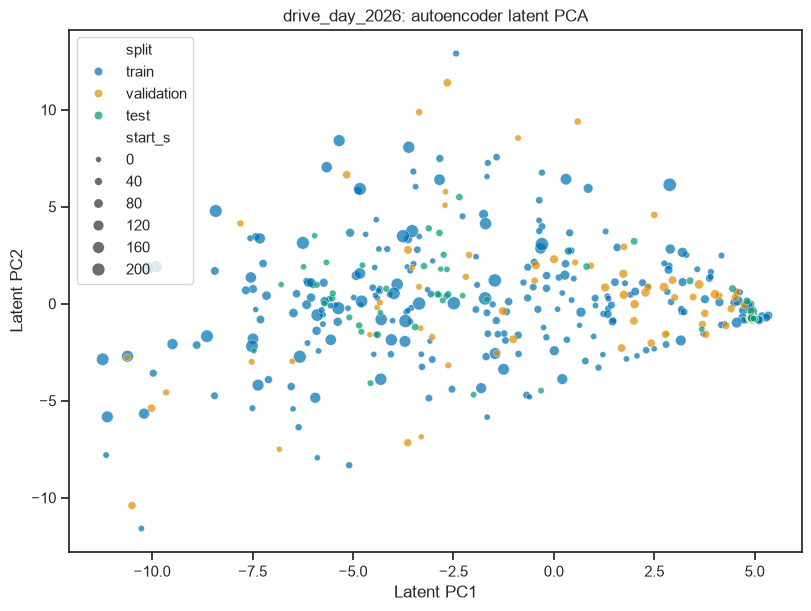

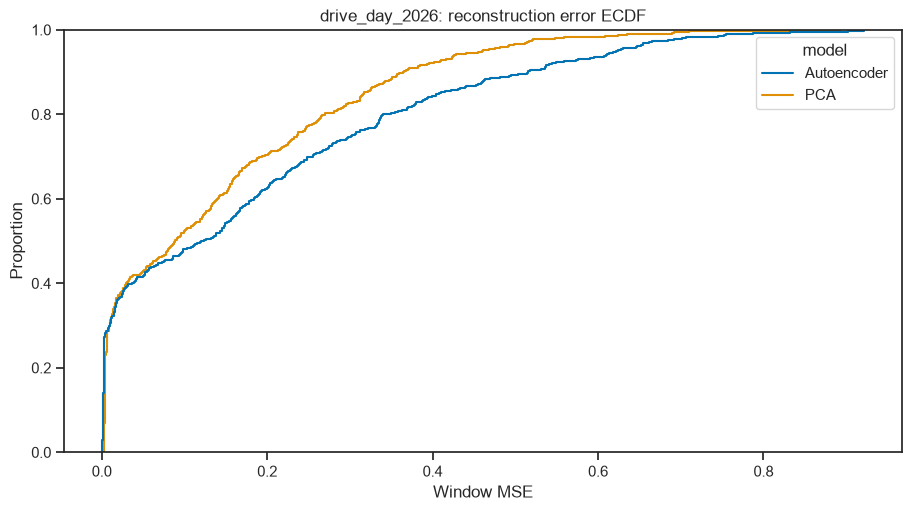

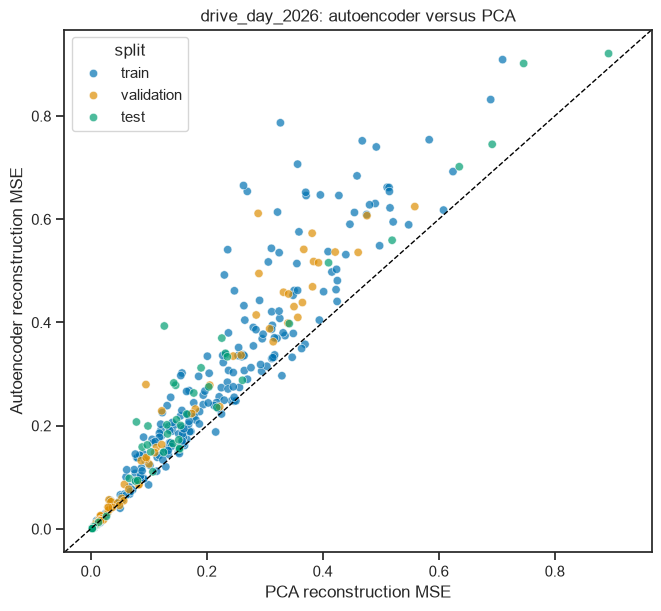

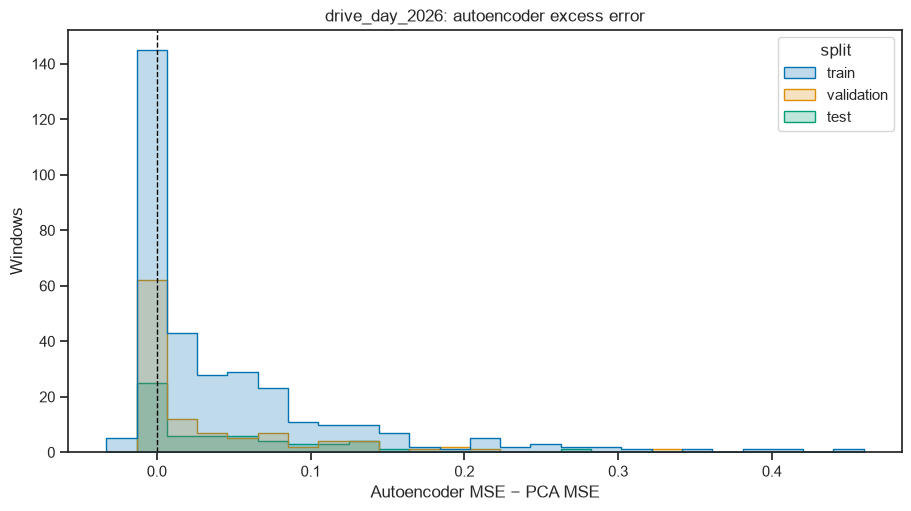

C:\Users\randl\Documents\GitHub\Lap_Estimation\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


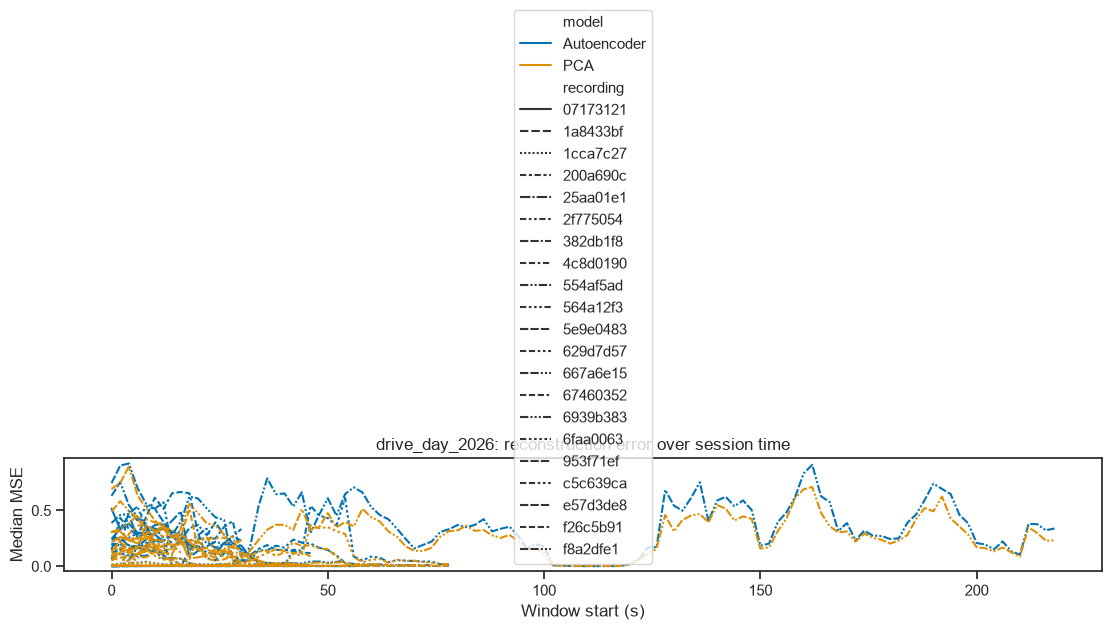

In [3]:
METHOD = "05_autoencoders"
result = run_experiment(METHOD, ROOT, dataset_key=DATASET_KEY, **EXPERIMENT_OPTIONS)
run_manifest = json.loads((result.output_dir / "manifest.json").read_text(encoding="utf-8"))
display(result.metrics)
display(result.predictions.describe(include="all").T)
display(result.predictions.groupby("recording_id")["score"].agg(["count", "mean", "median", "std", "min", "max"]).sort_values("median", ascending=False))
diagnostic_figures = render_autoencoder_diagnostics(result.predictions, run_manifest, result.output_dir)
for figure in diagnostic_figures.values():
    display(figure)
    plt.close(figure)

In [4]:
pd.Series(
    {
        "status": run_manifest["status"],
        "runtime_s": run_manifest["runtime_s"],
        "clock_provenance": run_manifest["data_provenance"]["clock_provenance"],
        "sample_rate_hz": run_manifest["data_provenance"]["native_sample_rate_hz"],
        "channels": run_manifest["data_provenance"]["selected_channels"],
        "label_provenance": run_manifest["label_provenance"],
    },
    name="value",
).to_frame()

,value
status,complete
runtime_s,2.57
clock_provenance,recorded_time_column
sample_rate_hz,10.0
channels,"[Motor RPM [Rpm], MC Duty Cycle [%], AC Curren..."
label_provenance,reconstruction_score_unverified


## Reading

Lower error than PCA supports representation efficiency only. Anomalies are not boundaries.

No lap precision, recall, count error, or duration error can be reported without independently reviewed boundaries.